In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
column_names = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet_Content']
df_train = pd.read_csv(r'data/twitter_training.csv',names=column_names)

In [6]:
df_train.head()

,Tweet_ID,Entity,Sentiment,Tweet_Content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [7]:
df_test = pd.read_csv(r'data/twitter_validation.csv',names=column_names)

In [8]:
df_test.head()

,Tweet_ID,Entity,Sentiment,Tweet_Content
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [9]:
df_train.shape, df_test.shape

((74682, 4), (1000, 4))

In [10]:
df_train.isnull().sum()

Tweet_ID           0
Entity             0
Sentiment          0
Tweet_Content    686
dtype: int64

In [11]:
df_train.dropna(inplace=True)

In [12]:
df_train.isnull().sum()

Tweet_ID         0
Entity           0
Sentiment        0
Tweet_Content    0
dtype: int64

In [13]:
df_test.isnull().sum()

Tweet_ID         0
Entity           0
Sentiment        0
Tweet_Content    0
dtype: int64

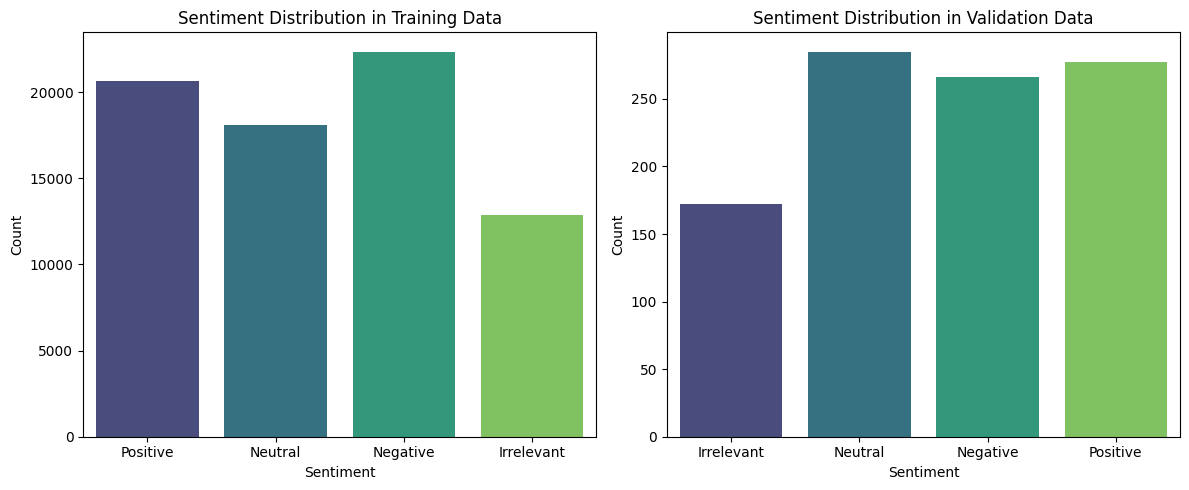

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df_train, x='Sentiment', palette='viridis')
plt.title('Sentiment Distribution in Training Data')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(data=df_test, x='Sentiment', palette='viridis')
plt.title('Sentiment Distribution in Validation Data')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
#NLP 
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab') 

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


In [18]:
def preprocess_text(text):
    if not isinstance(text, str): 
        return ""
    
    #Lowercasing
    text = text.lower()

    #Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(processed_tokens)

In [19]:
df_train['processed_content'] = df_train['Tweet_Content'].apply(preprocess_text)
df_test['processed_content'] = df_test['Tweet_Content'].apply(preprocess_text)

In [20]:
df_train[['Tweet_Content', 'processed_content']].head()


,Tweet_Content,processed_content
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland 2 murder


In [21]:
df_test[['Tweet_Content', 'processed_content']].head()

,Tweet_Content,processed_content
0,I mentioned on Facebook that I was struggling ...,mentioned facebook struggling motivation go ru...
1,BBC News - Amazon boss Jeff Bezos rejects clai...,bbc news amazon bos jeff bezos reject claim co...
2,@Microsoft Why do I pay for WORD when it funct...,microsoft pay word function poorly samsungus c...
3,"CSGO matchmaking is so full of closet hacking,...",csgo matchmaking full closet hacking truly awf...
4,Now the President is slapping Americans in the...,president slapping american face really commit...


In [22]:
sentiments = df_train['Sentiment'].unique()
print(sentiments)

['Positive' 'Neutral' 'Negative' 'Irrelevant']


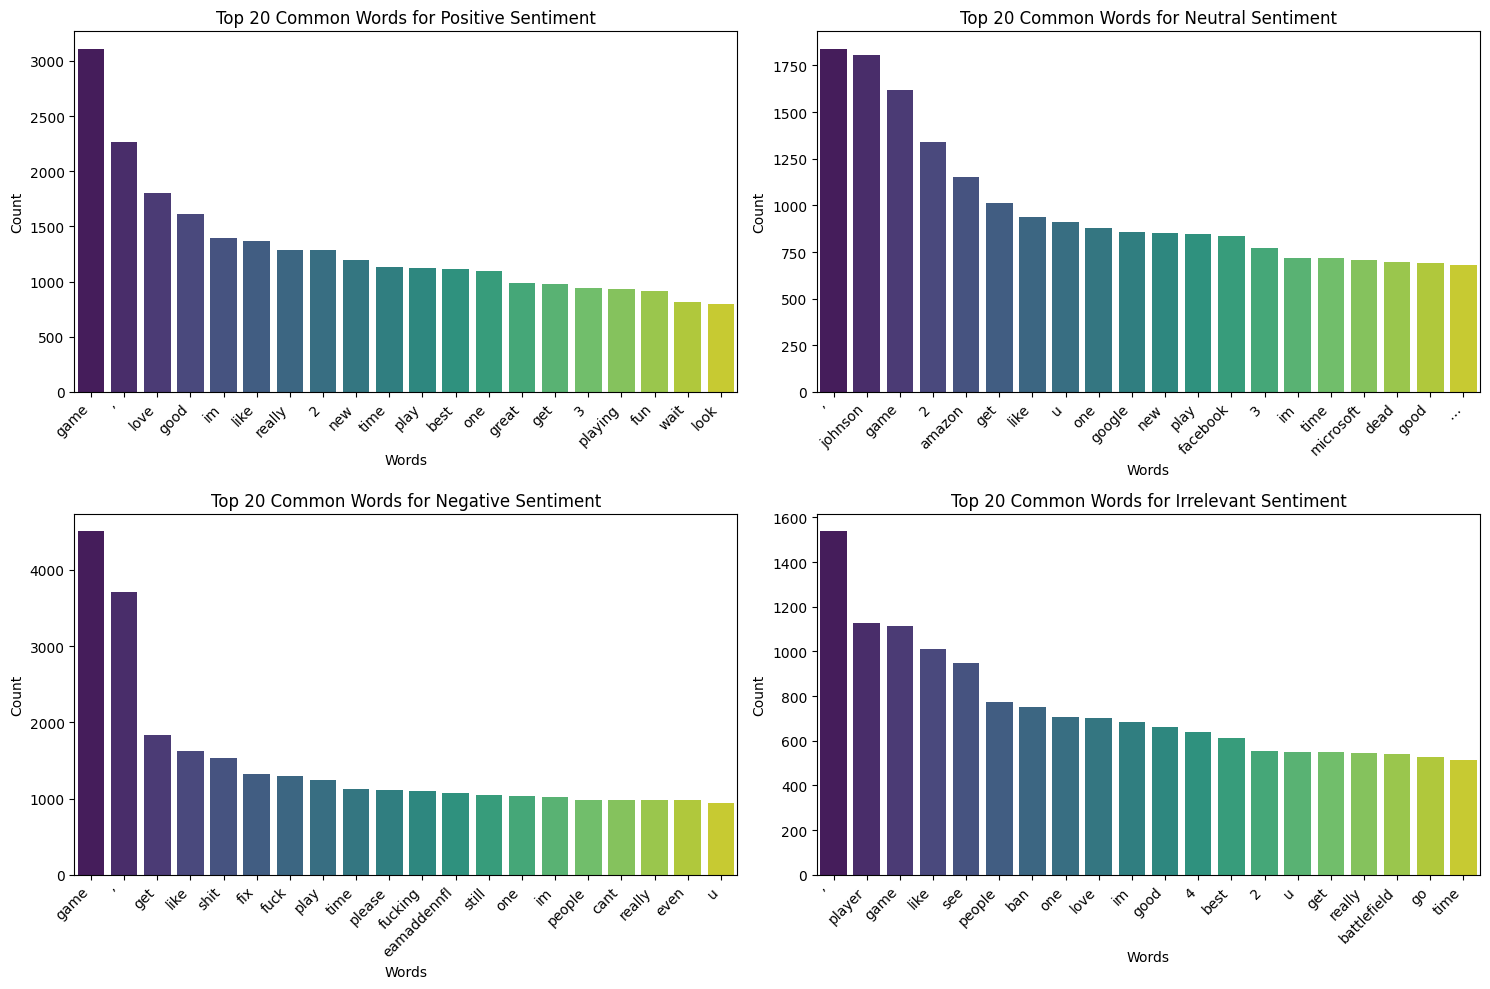

In [23]:
from collections import Counter

def get_top_n_words(corpus, n=None):
    words = []
    for sentence in corpus:
        words.extend(sentence.split())
    return Counter(words).most_common(n)

sentiments = df_train['Sentiment'].unique()

plt.figure(figsize=(15, 10))

for i, sentiment in enumerate(sentiments):
    sentiment_df = df_train[df_train['Sentiment'] == sentiment]
    processed_corpus = sentiment_df['processed_content']

    top_words = get_top_n_words(processed_corpus, n=20)
    
    if top_words:
        words, counts = zip(*top_words)
        
        plt.subplot(2, 2, i + 1)
        sns.barplot(x=list(words), y=list(counts), palette='viridis')
        plt.title(f'Top 20 Common Words for {sentiment} Sentiment')
        plt.xlabel('Words')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000) 

X_train_tfidf = tfidf_vectorizer.fit_transform(df_train['processed_content'])
X_val_tfidf = tfidf_vectorizer.transform(df_test['processed_content'])

In [25]:
X_val_tfidf.toarray()[1]

array([0., 0., 0., ..., 0., 0., 0.], shape=(5000,))

In [26]:
X_train_tfidf.shape, X_val_tfidf.shape

((73996, 5000), (1000, 5000))

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_train['encoded_sentiment'] = le.fit_transform(df_train['Sentiment'])
df_test['encoded_sentiment'] = le.transform(df_test['Sentiment'])


In [61]:
# import joblib
# joblib.dump(le.classes_, "label_classes.pkl")

['label_classes.pkl']

In [28]:
df_train.head()

,Tweet_ID,Entity,Sentiment,Tweet_Content,processed_content,encoded_sentiment
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting borderland murder,3
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,coming border kill,3
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting borderland kill,3
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming borderland murder,3
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting borderland 2 murder,3


In [29]:
df_train['encoded_sentiment'].value_counts()

encoded_sentiment
1    22358
3    20655
2    18108
0    12875
Name: count, dtype: int64

In [30]:
le.classes_

array(['Irrelevant', 'Negative', 'Neutral', 'Positive'], dtype=object)

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

lr = LogisticRegression(max_iter=1000, random_state=42)

print(lr.fit(X_train_tfidf, df_train['encoded_sentiment']))

LogisticRegression(max_iter=1000, random_state=42)


In [32]:
y_pred = lr.predict(X_val_tfidf)

In [33]:
accuracy_score(df_test['encoded_sentiment'], y_pred)

0.811

In [34]:
print(classification_report(df_test['encoded_sentiment'], y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

  Irrelevant       0.82      0.72      0.77       172
    Negative       0.78      0.87      0.82       266
     Neutral       0.85      0.76      0.80       285
    Positive       0.81      0.87      0.83       277

    accuracy                           0.81      1000
   macro avg       0.81      0.80      0.81      1000
weighted avg       0.81      0.81      0.81      1000



In [ ]:
# import joblib
# joblib.dump(tfidf_vectorizer, "tfidf.pkl")
# joblib.dump(lr, "logreg.pkl")


['logreg.pkl']

In [35]:
lr.predict(tfidf_vectorizer.transform(["this is funny"]))

array([0])

In [37]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

print(nb.fit(X_train_tfidf, df_train['encoded_sentiment']))

MultinomialNB()


In [38]:

y_pred_nb = nb.predict(X_val_tfidf)

In [39]:
accuracy_score(df_test['encoded_sentiment'], y_pred_nb)


0.714

In [40]:

print(classification_report(df_test['encoded_sentiment'], y_pred_nb, target_names=le.classes_))

              precision    recall  f1-score   support

  Irrelevant       0.84      0.54      0.66       172
    Negative       0.66      0.84      0.74       266
     Neutral       0.79      0.58      0.67       285
    Positive       0.68      0.83      0.75       277

    accuracy                           0.71      1000
   macro avg       0.74      0.70      0.70      1000
weighted avg       0.73      0.71      0.71      1000



<Figure size 1000x800 with 0 Axes>

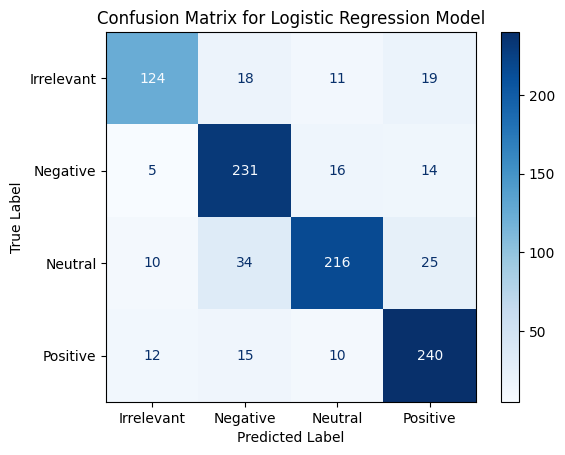

<Figure size 1000x800 with 0 Axes>

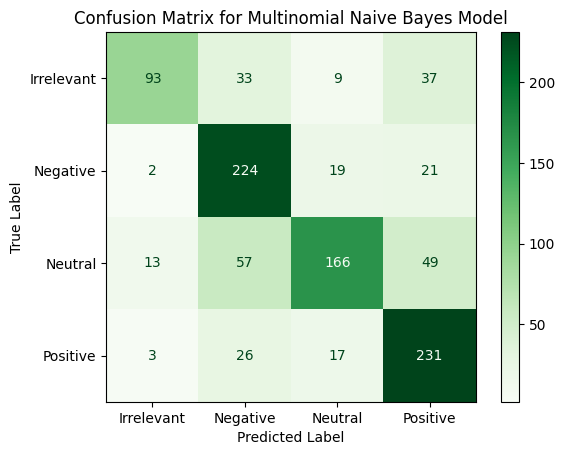

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay


cm_log_reg = confusion_matrix(df_test['encoded_sentiment'], y_pred)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=le.classes_)

plt.figure(figsize=(10, 8))
disp_log_reg.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.show()


cm_nb = confusion_matrix(df_test['encoded_sentiment'], y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=le.classes_)

plt.figure(figsize=(10, 8))
disp_nb.plot(cmap=plt.cm.Greens, values_format='d')
plt.title('Confusion Matrix for Multinomial Naive Bayes Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.show()

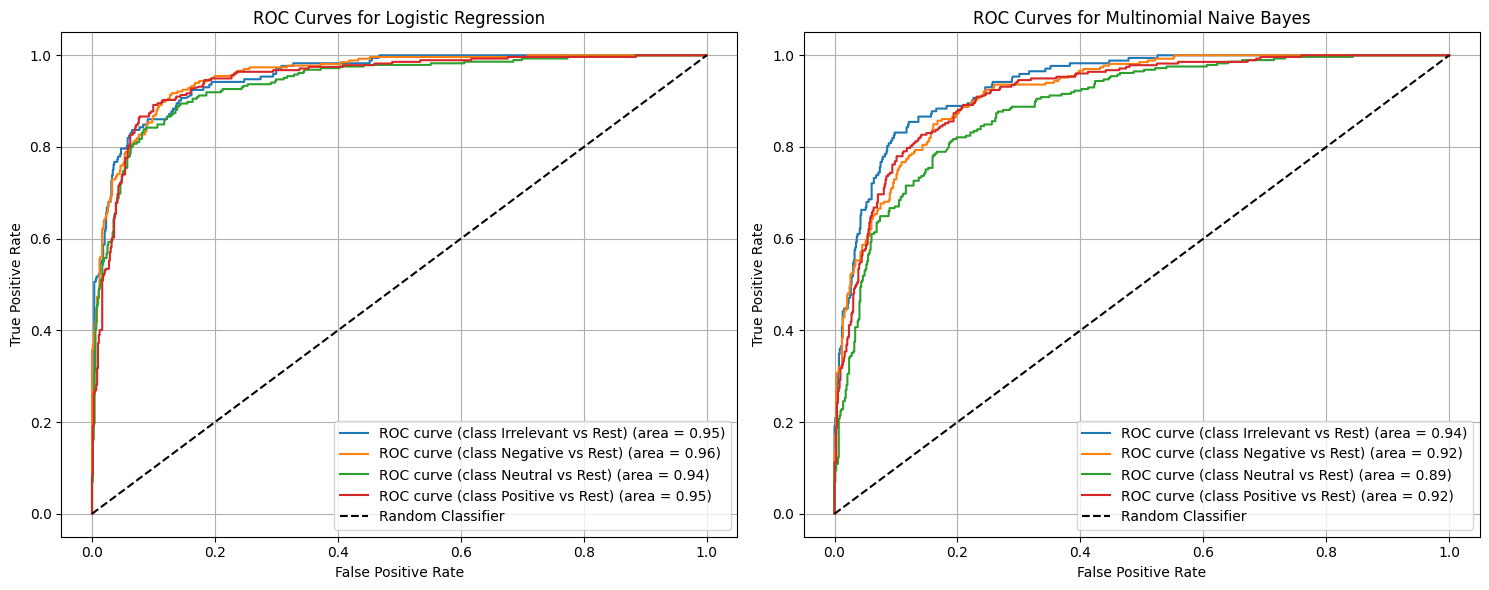

In [42]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize


y_true_binarized = label_binarize(df_test['encoded_sentiment'], classes=np.unique(df_test['encoded_sentiment']))
n_classes = y_true_binarized.shape[1]

plt.figure(figsize=(15, 6))

#ROC curve for Logistic Regression 
plt.subplot(1, 2, 1)
plt.title('ROC Curves for Logistic Regression')

y_score_log_reg = lr.predict_proba(X_val_tfidf)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_score_log_reg[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (class {le.classes_[i]} vs Rest) (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)

#ROC Curve for Multinomial Naive Bayes
plt.subplot(1, 2, 2)
plt.title('ROC Curves for Multinomial Naive Bayes')

y_score_nb = nb.predict_proba(X_val_tfidf)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_score_nb[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (class {le.classes_[i]} vs Rest) (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Moving to more advanced models

In [43]:
def preprocess_text(text):
    if not isinstance(text, str): 
        return ""
    
    #Lowercasing
    text = text.lower()

    #Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

In [44]:
df_train['processed_content_nn'] = df_train['Tweet_Content'].apply(preprocess_text)
df_test['processed_content_nn'] = df_test['Tweet_Content'].apply(preprocess_text)

In [45]:
df_train.head()

,Tweet_ID,Entity,Sentiment,Tweet_Content,processed_content,encoded_sentiment,processed_content_nn
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,im getting borderland murder,3,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,coming border kill,3,i am coming to the borders and i will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,im getting borderland kill,3,im getting on borderlands and i will kill you all
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,im coming borderland murder,3,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,im getting borderland 2 murder,3,im getting on borderlands 2 and i will murder ...


In [46]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=10000, oov_token="<unk>")

tokenizer.fit_on_texts(df_train['processed_content_nn'])


X_train_sequences = tokenizer.texts_to_sequences(df_train['processed_content_nn'])
X_val_sequences = tokenizer.texts_to_sequences(df_test['processed_content_nn'])

maxlen = max(len(x) for x in X_train_sequences)

X_train_padded = pad_sequences(X_train_sequences, maxlen=maxlen, padding='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=maxlen, padding='post')


print("Shape of X_train_padded:", X_train_padded.shape)
print("Shape of X_val_padded:", X_val_padded.shape)

Shape of X_train_padded: (73996, 166)
Shape of X_val_padded: (1000, 166)


In [ ]:
import joblib
joblib.dump(maxlen, "max_len.pkl")

['max_len.pkl']

In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense


vocab_size = tokenizer.num_words 

embedding_dim = 128

model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen))

model.add(Flatten())

In [48]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [49]:
model.add(Dense(128, activation='relu')) 
model.add(Dense(64, activation='relu'))
num_classes = len(le.classes_)
model.add(Dense(num_classes, activation='softmax'))

In [50]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(
    X_train_padded, df_train['encoded_sentiment'],
    epochs=10, 
    batch_size=128, 
    validation_data=(X_val_padded, df_test['encoded_sentiment'])
)

Epoch 1/10
579/579 ━━━━━━━━━━━━━━━━━━━━ 50s 82ms/step - accuracy: 0.6358 - loss: 0.8727 - val_accuracy: 0.9170 - val_loss: 0.2563
Epoch 2/10
579/579 ━━━━━━━━━━━━━━━━━━━━ 52s 89ms/step - accuracy: 0.8893 - loss: 0.3013 - val_accuracy: 0.9630 - val_loss: 0.1196
Epoch 3/10
579/579 ━━━━━━━━━━━━━━━━━━━━ 52s 89ms/step - accuracy: 0.9403 - loss: 0.1594 - val_accuracy: 0.9620 - val_loss: 0.1266
Epoch 4/10
579/579 ━━━━━━━━━━━━━━━━━━━━ 56s 96ms/step - accuracy: 0.9534 - loss: 0.1191 - val_accuracy: 0.9650 - val_loss: 0.1111
Epoch 5/10
579/579 ━━━━━━━━━━━━━━━━━━━━ 79s 92ms/step - accuracy: 0.9586 - loss: 0.1019 - val_accuracy: 0.9610 - val_loss: 0.1440
Epoch 6/10
579/579 ━━━━━━━━━━━━━━━━━━━━ 53s 91ms/step - accuracy: 0.9606 - loss: 0.0979 - val_accuracy: 0.9600 - val_loss: 0.1616
Epoch 7/10
579/579 ━━━━━━━━━━━━━━━━━━━━ 68s 66ms/step - accuracy: 0.9590 - loss: 0.1006 - val_accuracy: 0.9610 - val_loss: 0.1675
Epoch 8/10
579/579 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9618 - loss: 0.0913 - 

In [ ]:
# model_filename = 'sentiment_analysis.keras'
# model.save(model_filename)

In [52]:
import tensorflow as tf
loaded_model = tf.keras.models.load_model('sentiment_analysis.keras')

loss, accuracy = loaded_model.evaluate(X_val_padded, df_test['encoded_sentiment'], verbose=0)
print(f"model accuracy on test data: {accuracy*100:.2f}%")

model accuracy on test data: 96.10%


In [53]:
print(loaded_model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 166, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 21248)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,719,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,025,166 (45.87 MB)

 Trainable params: 4,008,388 (15.29 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,016,778 (30.58 MB)

None


In [54]:

y_pred_ann_raw = loaded_model.predict(X_val_padded,verbose=0)
y_pred_ann = np.argmax(y_pred_ann_raw, axis=1)


print(classification_report(df_test['encoded_sentiment'], y_pred_ann, target_names=le.classes_))

              precision    recall  f1-score   support

  Irrelevant       0.94      0.98      0.96       172
    Negative       0.97      0.97      0.97       266
     Neutral       0.95      0.96      0.95       285
    Positive       0.98      0.94      0.96       277

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



In [62]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(df_test['encoded_sentiment'], y_pred_ann)
print("Accuracy:", accuracy)

Accuracy: 0.961


<Figure size 1000x800 with 0 Axes>

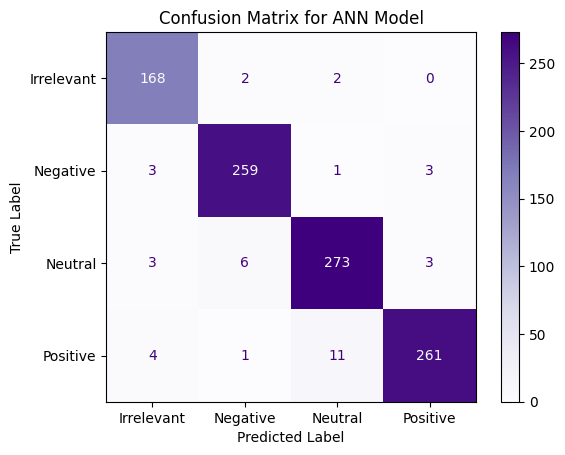

In [55]:
cm_ann = confusion_matrix(df_test['encoded_sentiment'], y_pred_ann)
disp_ann = ConfusionMatrixDisplay(confusion_matrix=cm_ann, display_labels=le.classes_)

plt.figure(figsize=(10, 8))
disp_ann.plot(cmap=plt.cm.Purples, values_format='d')
plt.title('Confusion Matrix for ANN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.grid(False)
plt.show()

In [60]:
# import joblib
# joblib.dump(disp_ann, "conf_matrix.pkl")

['conf_matrix.pkl']

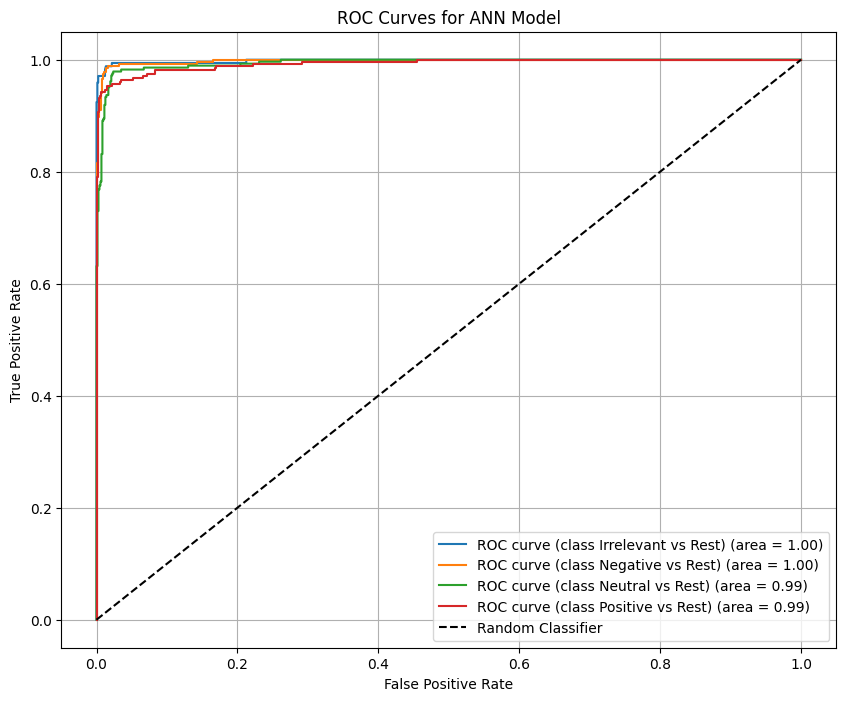

In [58]:
y_true_binarized = label_binarize(df_test['encoded_sentiment'], classes=np.unique(df_test['encoded_sentiment']))
n_classes = y_true_binarized.shape[1]

y_score_ann = loaded_model.predict(X_val_padded,verbose=0)

plt.figure(figsize=(10, 8))
plt.title('ROC Curves for ANN Model')

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_score_ann[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve (class {le.classes_[i]} vs Rest) (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [64]:
def predict_sentiment_ann(text, model, tokenizer, maxlen, label_encoder, preprocess_func):
    processed_text = preprocess_func(text)

    sequence = tokenizer.texts_to_sequences([processed_text])

    padded_sequence = pad_sequences(sequence, maxlen=maxlen, padding='post')

    prediction_raw = model.predict(padded_sequence)
    predicted_class = np.argmax(prediction_raw, axis=1)[0]

    sentiment_label = label_encoder.inverse_transform([predicted_class])[0]

    return sentiment_label, prediction_raw[0]

new_tweet = "it's terrible"
predicted_sentiment= predict_sentiment_ann(
    new_tweet, loaded_model, tokenizer, maxlen, le, preprocess_text
)

print(f"Original Tweet: {new_tweet}")
print(f"Predicted Sentiment: {predicted_sentiment}")

new_tweet_2 = "not good."
predicted_sentiment_2 = predict_sentiment_ann(
    new_tweet_2, loaded_model, tokenizer, maxlen, le, preprocess_text
)

print(f"\nOriginal Tweet: {new_tweet_2}")
print(f"Predicted Sentiment: {predicted_sentiment_2}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Original Tweet: it's terrible
Predicted Sentiment: ('Negative', array([0.02861927, 0.91406274, 0.02379269, 0.03352528], dtype=float32))
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Original Tweet: not good.
Predicted Sentiment: ('Negative', array([0.24858013, 0.3977631 , 0.15195675, 0.20170002], dtype=float32))
